# Notebook 05 — Seleção do Modelo de Sentimento

**Objetivo**: correlacionar cada série de sentimento (Notebook 04) com a série de inadimplência (Notebook 01) e selecionar os **3 melhores modelos** para uso na modelagem final.

**Modelos avaliados**: BERT Multilingual, FinBERT-PT-BR, TextBlob, NLTK/VADER, Mistral + Média dos 5 (modelo 6)  
**Entrada**: `base_series.csv` + `base_sentimentos.csv`  
**Saída**: `base_sentimento_selecionado.csv`

In [6]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 1. Carregamento das bases

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Série de Inadimplência (Notebook 01) ────────────────────────────────────
URL_INAD = "https://raw.githubusercontent.com/akemitti/Pred-inad-credito/main/base_series.csv"
try:
    df_inad = pd.read_csv("base_series.csv")
    print("base_series.csv carregado do disco.")
except FileNotFoundError:
    df_inad = pd.read_csv(URL_INAD)
    print("base_series.csv carregado do GitHub.")

df_inad.columns = [c.strip().lower() for c in df_inad.columns]
df_inad["data"] = pd.to_datetime(df_inad["data"], errors="coerce")
df_inad = df_inad[["data", "inad_total"]].dropna().sort_values("data").reset_index(drop=True)

# ── Scores de Sentimento (Notebook 04) ──────────────────────────────────────
URL_SENT = "https://raw.githubusercontent.com/akemitti/Pred-inad-credito/main/base_sentimentos.csv"
try:
    df_sent = pd.read_csv("base_sentimentos.csv")
    print("base_sentimentos.csv carregado do disco.")
except FileNotFoundError:
    df_sent = pd.read_csv(URL_SENT)
    print("base_sentimentos.csv carregado do GitHub.")

df_sent.columns = [c.strip().lower() for c in df_sent.columns]
df_sent["data"] = pd.to_datetime(df_sent["data"], errors="coerce")

# Identificar colunas de score
score_cols_raw = [c for c in df_sent.columns if c.startswith("score_")]
print(f"Scores disponíveis: {score_cols_raw}")


base_series.csv carregado do disco.
base_sentimentos.csv carregado do disco.
Scores disponíveis: ['score_nltk', 'score_textblob', 'score_bert', 'score_finbert', 'score_mistral']


## 2. Agregação mensal com grade completa e interpolação

A base consolidada do Notebook 04 contém duas origens textuais: **Atas do Copom** e **Relatórios de Estatísticas Monetárias e de Crédito**.

Como as Atas do Copom não são publicadas necessariamente todos os meses, e os Relatórios de Estatísticas podem ter lacunas pontuais, a análise precisa criar uma **grade mensal completa** de `2019-01-01` até `2025-12-01` para cada tipo de relatório.

A regra aplicada é:

1. agregar os scores por mês e tipo de relatório;
2. criar todos os meses do período para `copom` e `estatisticas`;
3. preencher meses faltantes por **interpolação linear**;
4. preencher bordas sem observação anterior/posterior com `bfill/ffill`;
5. manter uma coluna de rastreabilidade indicando se o mês era original ou foi preenchido.

In [16]:
df_sent_completo = df_sent.copy()

if "tipo_relatorio" not in df_sent_completo.columns:
    # fallback: caso alguma versão antiga tenha usado a coluna 'tipo'
    if "tipo" in df_sent_completo.columns:
        df_sent_completo["tipo_relatorio"] = df_sent_completo["tipo"]
    else:
        raise ValueError(
            "A coluna 'tipo_relatorio' não foi encontrada na base_sentimentos.csv. "
            "Verifique se o Notebook 04 exportou a base consolidada com Copom e Estatísticas."
        )

df_sent_completo["tipo_relatorio"] = (
    df_sent_completo["tipo_relatorio"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Manter apenas os dois tipos esperados
TIPOS_VALIDOS = ["copom", "estatisticas"]

df_sent_completo = df_sent_completo[
    df_sent_completo["tipo_relatorio"].isin(TIPOS_VALIDOS)
].copy()

# Garantir que a data está em formato datetime
df_sent_completo["data"] = pd.to_datetime(df_sent_completo["data"], errors="coerce")
df_sent_completo = df_sent_completo.dropna(subset=["data"])

print("Distribuição da base completa por tipo de relatório:")
display(
    df_sent_completo["tipo_relatorio"]
    .value_counts()
    .rename_axis("tipo_relatorio")
    .reset_index(name="qtd_registros")
)

# ── Definir a grade mensal completa da análise ──────────────────────────────
# Período usado no TCC para comparação com a inadimplência.
PERIODO_INICIO = "2019-01-01"
PERIODO_FIM = "2025-12-01"

grade_mensal = pd.date_range(
    start=PERIODO_INICIO,
    end=PERIODO_FIM,
    freq="MS"  # MS = Month Start, ou seja, primeiro dia de cada mês
)

print(f"Grade mensal esperada: {len(grade_mensal)} meses")
print(f"Período: {grade_mensal.min().date()} a {grade_mensal.max().date()}")

# ── Função auxiliar para agregação mensal + preenchimento dos meses faltantes ─
def agregar_mensal_com_interpolacao(df_base, tipo_relatorio, score_cols_raw, grade_mensal):
    """
    Agrega os scores de sentimento por mês para um tipo específico de relatório
    e preenche os meses faltantes para manter uma série mensal completa.

    Interpolação linear:
    - usada para preencher lacunas internas entre dois meses observados.

    bfill/ffill:
    - usados apenas nas bordas, quando não há observação anterior ou posterior
      suficiente para interpolação, como o início da série de Copom em jan/2019.
    """

    df_tipo = df_base[df_base["tipo_relatorio"] == tipo_relatorio].copy()

    if df_tipo.empty:
        raise ValueError(f"Não há registros para tipo_relatorio = '{tipo_relatorio}'.")

    # Converter a data do documento para o mês de referência
    df_tipo["mes"] = df_tipo["data"].dt.to_period("M").dt.to_timestamp()

    # Agregar por mês.
    # Para Copom, isso mensaliza a ata do mês.
    # Para Estatísticas, mantém a estrutura mensal dos relatórios.
    df_mensal_observado = (
        df_tipo.groupby("mes")[score_cols_raw]
        .mean()
        .sort_index()
    )

    meses_observados = set(df_mensal_observado.index)

    # Reindexar para garantir todos os meses entre 2019-01 e 2025-12.
    # Os meses sem documento ficam como NaN antes do preenchimento.
    df_mensal = df_mensal_observado.reindex(grade_mensal)
    df_mensal.index.name = "data"
    df_mensal = df_mensal.reset_index()

    df_mensal["tipo_relatorio"] = tipo_relatorio
    df_mensal["registro_original"] = df_mensal["data"].isin(meses_observados)

    # Identificar meses ausentes antes do preenchimento
    df_mensal["mes_ausente_originalmente"] = ~df_mensal["registro_original"]

    # Preenchimento das lacunas internas por interpolação linear
    scores_interpolados = df_mensal[score_cols_raw].interpolate(
        method="linear",
        limit_area="inside"
    )

    # Marcar quais meses foram preenchidos por interpolação interna
    preenchido_por_interpolacao = (
        df_mensal["mes_ausente_originalmente"]
        & scores_interpolados.notna().any(axis=1)
    )

    # Preenchimento de bordas, quando não há valor anterior/posterior
    # Exemplo: Copom em jan/2019, porque a primeira ata da amostra ocorre em fev/2019.
    scores_finais = scores_interpolados.bfill().ffill()

    preenchido_por_borda = (
        df_mensal["mes_ausente_originalmente"]
        & ~preenchido_por_interpolacao
        & scores_finais.notna().any(axis=1)
    )

    df_mensal[score_cols_raw] = scores_finais

    df_mensal["metodo_preenchimento"] = np.select(
        [
            df_mensal["registro_original"],
            preenchido_por_interpolacao,
            preenchido_por_borda
        ],
        [
            "original",
            "interpolado",
            "bfill_ffill_borda"
        ],
        default="sem_valor"
    )

    return df_mensal

# ── Agregar e preencher separadamente ───────────────────────────────────────
df_sent_mensal_copom = agregar_mensal_com_interpolacao(
    df_sent_completo,
    "copom",
    score_cols_raw,
    grade_mensal
)

df_sent_mensal_estatisticas = agregar_mensal_com_interpolacao(
    df_sent_completo,
    "estatisticas",
    score_cols_raw,
    grade_mensal
)

# ── Juntar Copom + Estatísticas em uma única base mensal ────────────────────
df_sent_mensal = pd.concat(
    [df_sent_mensal_copom, df_sent_mensal_estatisticas],
    ignore_index=True
)

# Remover colunas de score com todos os valores ausentes
score_cols = [c for c in score_cols_raw if df_sent_mensal[c].notna().any()]

df_sent_mensal = df_sent_mensal[
    [
        "data",
        "tipo_relatorio",
        "registro_original",
        "mes_ausente_originalmente",
        "metodo_preenchimento",
    ] + score_cols
]

df_sent_mensal = (
    df_sent_mensal
    .sort_values(["tipo_relatorio", "data"])
    .reset_index(drop=True)
)

print(f"Scores mensais disponíveis: {score_cols}")

print("\nResumo por tipo de relatório:")
display(
    df_sent_mensal.groupby("tipo_relatorio")
    .agg(
        inicio=("data", "min"),
        fim=("data", "max"),
        qtd_meses=("data", "count"),
        meses_originais=("registro_original", "sum"),
        meses_preenchidos=("mes_ausente_originalmente", "sum"),
    )
    .reset_index()
)

print("\nMétodo de preenchimento por tipo de relatório:")
display(
    df_sent_mensal.groupby(["tipo_relatorio", "metodo_preenchimento"])
    .size()
    .reset_index(name="qtd_meses")
)

print("\nExemplo da base mensal final:")
display(df_sent_mensal.head(10))


Distribuição da base completa por tipo de relatório:


,tipo_relatorio,qtd_registros
0,estatisticas,81
1,copom,53


Grade mensal esperada: 84 meses
Período: 2019-01-01 a 2025-12-01
Scores mensais disponíveis: ['score_nltk', 'score_textblob', 'score_bert', 'score_finbert', 'score_mistral']

Resumo por tipo de relatório:


,tipo_relatorio,inicio,fim,qtd_meses,meses_originais,meses_preenchidos
0,copom,2019-01-01,2025-12-01,84,53,31
1,estatisticas,2019-01-01,2025-12-01,84,81,3



Método de preenchimento por tipo de relatório:


,tipo_relatorio,metodo_preenchimento,qtd_meses
0,copom,bfill_ffill_borda,1
1,copom,interpolado,30
2,copom,original,53
3,estatisticas,interpolado,3
4,estatisticas,original,81



Exemplo da base mensal final:


,data,tipo_relatorio,registro_original,mes_ausente_originalmente,metodo_preenchimento,score_nltk,score_textblob,score_bert,score_finbert,score_mistral
0,2019-01-01,copom,False,True,bfill_ffill_borda,-0.77830,0.00000,-0.071429,-0.248734,0.500
1,2019-02-01,copom,True,False,original,-0.77830,0.00000,-0.071429,-0.248734,0.500
2,2019-03-01,copom,True,False,original,-0.68080,0.00000,-0.062500,-0.336417,0.500
3,2019-04-01,copom,False,True,interpolado,-0.80410,0.03125,-0.093750,-0.362641,0.575
4,2019-05-01,copom,True,False,original,-0.92740,0.06250,-0.125000,-0.388865,0.650
5,2019-06-01,copom,True,False,original,-0.77830,0.00000,-0.187500,-0.407422,0.750
6,2019-07-01,copom,True,False,original,-0.84020,0.00000,0.062500,-0.227865,0.750
7,2019-08-01,copom,False,True,interpolado,-0.86045,0.00000,-0.031250,-0.216082,0.750
8,2019-09-01,copom,True,False,original,-0.88070,0.00000,-0.125000,-0.204299,0.750
9,2019-10-01,copom,True,False,original,-0.84020,0.00000,-0.250000,-0.250839,0.750


## 3. Modelo 6 — Média dos modelos de sentimento

In [19]:
# Sentimento médio dos modelos válidos
df_sent_mensal["score_media"] = df_sent_mensal[score_cols].mean(axis=1)
score_cols_todos = score_cols + ["score_media"]

print("Score médio (primeiros 5):")
df_sent_mensal



Score médio (primeiros 5):


,data,tipo_relatorio,registro_original,mes_ausente_originalmente,metodo_preenchimento,score_nltk,score_textblob,score_bert,score_finbert,score_mistral,score_media
0,2019-01-01,copom,False,True,bfill_ffill_borda,-0.7783,0.000000,-0.071429,-0.248734,0.500,-0.119692
1,2019-02-01,copom,True,False,original,-0.7783,0.000000,-0.071429,-0.248734,0.500,-0.119692
2,2019-03-01,copom,True,False,original,-0.6808,0.000000,-0.062500,-0.336417,0.500,-0.115943
3,2019-04-01,copom,False,True,interpolado,-0.8041,0.031250,-0.093750,-0.362641,0.575,-0.130848
4,2019-05-01,copom,True,False,original,-0.9274,0.062500,-0.125000,-0.388865,0.650,-0.145753
...,...,...,...,...,...,...,...,...,...,...,...
163,2025-08-01,estatisticas,True,False,original,-0.9894,0.000000,-0.916667,-0.018209,-0.100,-0.404855
164,2025-09-01,estatisticas,True,False,original,-0.9776,0.050000,-1.000000,0.007749,-0.600,-0.503970
165,2025-10-01,estatisticas,True,False,original,-0.9920,-0.400000,-1.000000,-0.007200,0.650,-0.349840
166,2025-11-01,estatisticas,True,False,original,-0.9898,-0.266667,-1.000000,0.292047,-0.300,-0.452884


## 4. Merge com a série de inadimplência

In [20]:
df_inad["mes"] = df_inad["data"].dt.to_period("M").dt.to_timestamp()
df_merged = df_inad.merge(
    df_sent_mensal.rename(columns={"data": "mes"}),
    on="mes", how="inner"
).sort_values("mes").reset_index(drop=True)

print(f"Observações após merge: {len(df_merged)}")
print(f"Período: {df_merged['mes'].min().date()} a {df_merged['mes'].max().date()}")

df_merged[["mes", "tipo_relatorio", "inad_total"] + score_cols_todos[:3]].head(10)


Observações após merge: 168
Período: 2019-01-01 a 2025-12-01


,mes,tipo_relatorio,inad_total,score_nltk,score_textblob,score_bert
0,2019-01-01,copom,2.95,-0.7783,0.000000,-0.071429
1,2019-01-01,estatisticas,2.95,-0.9969,-0.145455,-1.000000
2,2019-02-01,copom,2.91,-0.7783,0.000000,-0.071429
3,2019-02-01,estatisticas,2.91,-0.9872,-0.400000,-0.500000
4,2019-03-01,copom,2.99,-0.6808,0.000000,-0.062500
5,2019-03-01,estatisticas,2.99,-0.9911,-0.320000,-1.000000
6,2019-04-01,copom,3.02,-0.8041,0.031250,-0.093750
7,2019-04-01,estatisticas,3.02,-0.9934,-0.400000,-1.000000
8,2019-05-01,copom,3.05,-0.9274,0.062500,-0.125000
9,2019-05-01,estatisticas,3.05,-0.9903,0.000000,-1.000000


## 5. Análise de Correlação

Calculamos correlação de Pearson, Spearman e também com defasagens (lag 1, 3, 6 meses) do sentimento em relação à inadimplência.

In [22]:
resultados = []

nomes_display = {
    "score_nltk":     "NLTK/VADER",
    "score_textblob": "TextBlob",
    "score_bert":     "BERT Multilingual",
    "score_finbert":  "FinBERT-PT-BR",
    "score_mistral":  "Mistral",
    "score_media":    "Média dos Modelos",
}

# Garantir ordenação correta antes do cálculo dos lags
df_merged = df_merged.sort_values(["tipo_relatorio", "mes"]).reset_index(drop=True)

# Calcular correlação separadamente para cada tipo de relatório
for tipo_relatorio, df_tipo in df_merged.groupby("tipo_relatorio"):

    df_tipo = df_tipo.sort_values("mes").copy()

    for col in score_cols_todos:
        for lag in [0, 1, 3, 6]:

            # Aplicar lag apenas dentro do tipo de relatório analisado
            serie_lag = df_tipo[col].shift(lag)

            df_tmp = pd.DataFrame({
                "inad": df_tipo["inad_total"],
                "sent": serie_lag
            }).dropna()

            if len(df_tmp) < 5:
                continue

            r_pearson,  p_pearson  = stats.pearsonr(df_tmp["inad"], df_tmp["sent"])
            r_spearman, p_spearman = stats.spearmanr(df_tmp["inad"], df_tmp["sent"])

            resultados.append({
                "Tipo Relatório": tipo_relatorio,
                "Modelo":         nomes_display.get(col, col),
                "col":            col,
                "Lag (meses)":    lag,
                "Pearson r":      round(r_pearson, 4),
                "Pearson p":      round(p_pearson, 4),
                "Spearman r":     round(r_spearman, 4),
                "Spearman p":     round(p_spearman, 4),
                "|Pearson r|":    round(abs(r_pearson), 4),
                "N observações":  len(df_tmp)
            })

df_corr = pd.DataFrame(resultados)

print("=== Tabela Completa de Correlações por Tipo de Relatório ===")

display(
    df_corr
    .sort_values(["Tipo Relatório", "|Pearson r|"], ascending=[True, False])
    .head(40)
)

=== Tabela Completa de Correlações por Tipo de Relatório ===


,Tipo Relatório,Modelo,col,Lag (meses),Pearson r,Pearson p,Spearman r,Spearman p,|Pearson r|,N observações
19,copom,Mistral,score_mistral,6,-0.5468,0.0000,-0.5542,0.0000,0.5468,78
1,copom,NLTK/VADER,score_nltk,1,0.4699,0.0000,0.4916,0.0000,0.4699,83
0,copom,NLTK/VADER,score_nltk,0,0.4606,0.0000,0.4959,0.0000,0.4606,84
18,copom,Mistral,score_mistral,3,-0.4403,0.0000,-0.4375,0.0000,0.4403,81
2,copom,NLTK/VADER,score_nltk,3,0.4184,0.0001,0.4258,0.0001,0.4184,81
23,copom,Média dos Modelos,score_media,6,-0.4132,0.0002,-0.3708,0.0008,0.4132,78
3,copom,NLTK/VADER,score_nltk,6,0.3601,0.0012,0.3957,0.0003,0.3601,78
22,copom,Média dos Modelos,score_media,3,-0.3237,0.0032,-0.3143,0.0043,0.3237,81
17,copom,Mistral,score_mistral,1,-0.3034,0.0053,-0.3405,0.0016,0.3034,83
11,copom,BERT Multilingual,score_bert,6,0.2701,0.0168,0.2385,0.0355,0.2701,78


## 6. Seleção dos melhores modelos

In [24]:
df_best_lag = (
    df_corr.sort_values("|Pearson r|", ascending=False)
           .groupby(["Tipo Relatório", "col"])
           .first()
           .reset_index()
           .sort_values("|Pearson r|", ascending=False)
)

print("=== Melhor Correlação por Modelo, Tipo de Relatório e Melhor Lag ===")

display(
    df_best_lag[
        [
            "Tipo Relatório",
            "Modelo",
            "Lag (meses)",
            "Pearson r",
            "Spearman r",
            "|Pearson r|",
            "N observações"
        ]
    ].round(4)
)

=== Melhor Correlação por Modelo, Tipo de Relatório e Melhor Lag ===


,Tipo Relatório,Modelo,Lag (meses),Pearson r,Spearman r,|Pearson r|,N observações
3,copom,Mistral,6,-0.5468,-0.5542,0.5468,78
4,copom,NLTK/VADER,1,0.4699,0.4916,0.4699,83
2,copom,Média dos Modelos,6,-0.4132,-0.3708,0.4132,78
0,copom,BERT Multilingual,6,0.2701,0.2385,0.2701,78
11,estatisticas,TextBlob,6,0.2646,0.3000,0.2646,78
7,estatisticas,FinBERT-PT-BR,3,-0.2564,-0.3116,0.2564,81
9,estatisticas,Mistral,6,-0.1926,-0.0865,0.1926,78
5,copom,TextBlob,6,-0.1775,0.0712,0.1775,78
8,estatisticas,Média dos Modelos,3,-0.1360,-0.1914,0.1360,81
6,estatisticas,BERT Multilingual,1,-0.1047,-0.0936,0.1047,83


In [32]:
# Seleção: top 4 geral


candidatos = df_best_lag.copy()

top4 = candidatos.head(4).reset_index(drop=True)

print("\n=== TOP 4 MODELOS SELECIONADOS — GERAL ===")

display(
    top4[
        [
            "Tipo Relatório",
            "Modelo",
            "Lag (meses)",
            "Pearson r",
            "Spearman r",
            "|Pearson r|",
            "N observações"
        ]
    ].round(4)
)

# Lista estruturada com relatório, coluna e lag
top4_selecionados = top4[
    [
        "Tipo Relatório",
        "Modelo",
        "col",
        "Lag (meses)",
        "Pearson r",
        "Spearman r",
        "|Pearson r|"
    ]
].copy()

print("\n=== Selecionados para o Notebook 06 ===")
display(top4_selecionados.round(4))


=== TOP 4 MODELOS SELECIONADOS — GERAL ===


,Tipo Relatório,Modelo,Lag (meses),Pearson r,Spearman r,|Pearson r|,N observações
0,copom,Mistral,6,-0.5468,-0.5542,0.5468,78
1,copom,NLTK/VADER,1,0.4699,0.4916,0.4699,83
2,copom,Média dos Modelos,6,-0.4132,-0.3708,0.4132,78
3,copom,BERT Multilingual,6,0.2701,0.2385,0.2701,78



=== Selecionados para o Notebook 06 ===


,Tipo Relatório,Modelo,col,Lag (meses),Pearson r,Spearman r,|Pearson r|
0,copom,Mistral,score_mistral,6,-0.5468,-0.5542,0.5468
1,copom,NLTK/VADER,score_nltk,1,0.4699,0.4916,0.4699
2,copom,Média dos Modelos,score_media,6,-0.4132,-0.3708,0.4132
3,copom,BERT Multilingual,score_bert,6,0.2701,0.2385,0.2701


## 7. Visualização — Correlações

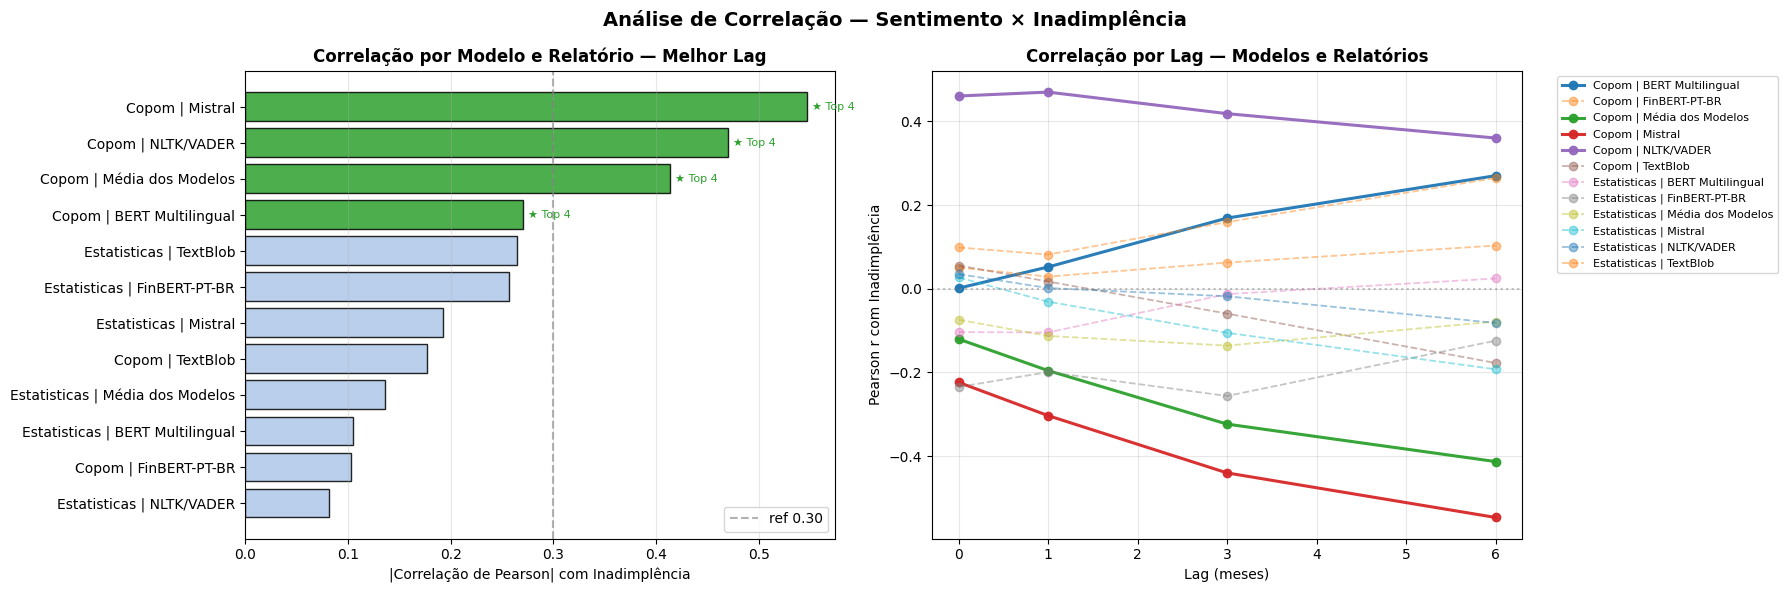

In [33]:
# Criar chave única para identificar relatório + modelo
df_best_lag["chave_modelo"] = df_best_lag["Tipo Relatório"] + "_" + df_best_lag["col"]
top4["chave_modelo"] = top4["Tipo Relatório"] + "_" + top4["col"]

top4_chaves = top4["chave_modelo"].tolist()

# Criar rótulo mais claro para o gráfico
df_best_lag["Modelo_Relatorio"] = (
    df_best_lag["Tipo Relatório"].str.capitalize()
    + " | "
    + df_best_lag["Modelo"]
)

df_corr["chave_modelo"] = df_corr["Tipo Relatório"] + "_" + df_corr["col"]
df_corr["Modelo_Relatorio"] = (
    df_corr["Tipo Relatório"].str.capitalize()
    + " | "
    + df_corr["Modelo"]
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# a) Bar chart de |Pearson r| por modelo e tipo de relatório
ax = axes[0]

df_plot_bar = df_best_lag.sort_values("|Pearson r|", ascending=True).copy()

cores_bar = [
    "#2ca02c" if chave in top4_chaves else "#aec7e8"
    for chave in df_plot_bar["chave_modelo"]
]

bars = ax.barh(
    df_plot_bar["Modelo_Relatorio"],
    df_plot_bar["|Pearson r|"],
    color=cores_bar,
    edgecolor="black",
    alpha=0.85
)

ax.axvline(
    0.3,
    color="gray",
    linestyle="--",
    alpha=0.6,
    label="ref 0.30"
)

ax.set_xlabel("|Correlação de Pearson| com Inadimplência")
ax.set_title("Correlação por Modelo e Relatório — Melhor Lag", fontweight="bold")
ax.legend()
ax.grid(True, axis="x", alpha=0.3)

# Legenda Top 4
for bar, chave in zip(bars, df_plot_bar["chave_modelo"]):
    if chave in top4_chaves:
        ax.text(
            bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            "★ Top 4",
            va="center",
            fontsize=8,
            color="#2ca02c"
        )

# b) Pearson r por lag para cada modelo e tipo de relatório
ax2 = axes[1]

for chave, sub in df_corr.groupby("chave_modelo"):

    sub = sub.sort_values("Lag (meses)")

    label = sub["Modelo_Relatorio"].iloc[0]

    ls = "-" if chave in top4_chaves else "--"
    lw = 2.2 if chave in top4_chaves else 1.3
    alpha = 0.95 if chave in top4_chaves else 0.45

    ax2.plot(
        sub["Lag (meses)"],
        sub["Pearson r"],
        marker="o",
        label=label,
        linestyle=ls,
        linewidth=lw,
        alpha=alpha
    )

ax2.axhline(0, color="gray", linestyle=":", alpha=0.5)

ax2.set_xlabel("Lag (meses)")
ax2.set_ylabel("Pearson r com Inadimplência")
ax2.set_title("Correlação por Lag — Modelos e Relatórios", fontweight="bold")
ax2.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")
ax2.grid(True, alpha=0.3)

plt.suptitle(
    "Análise de Correlação — Sentimento × Inadimplência",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 8. Scatter plots — Top 4 modelos vs Inadimplência

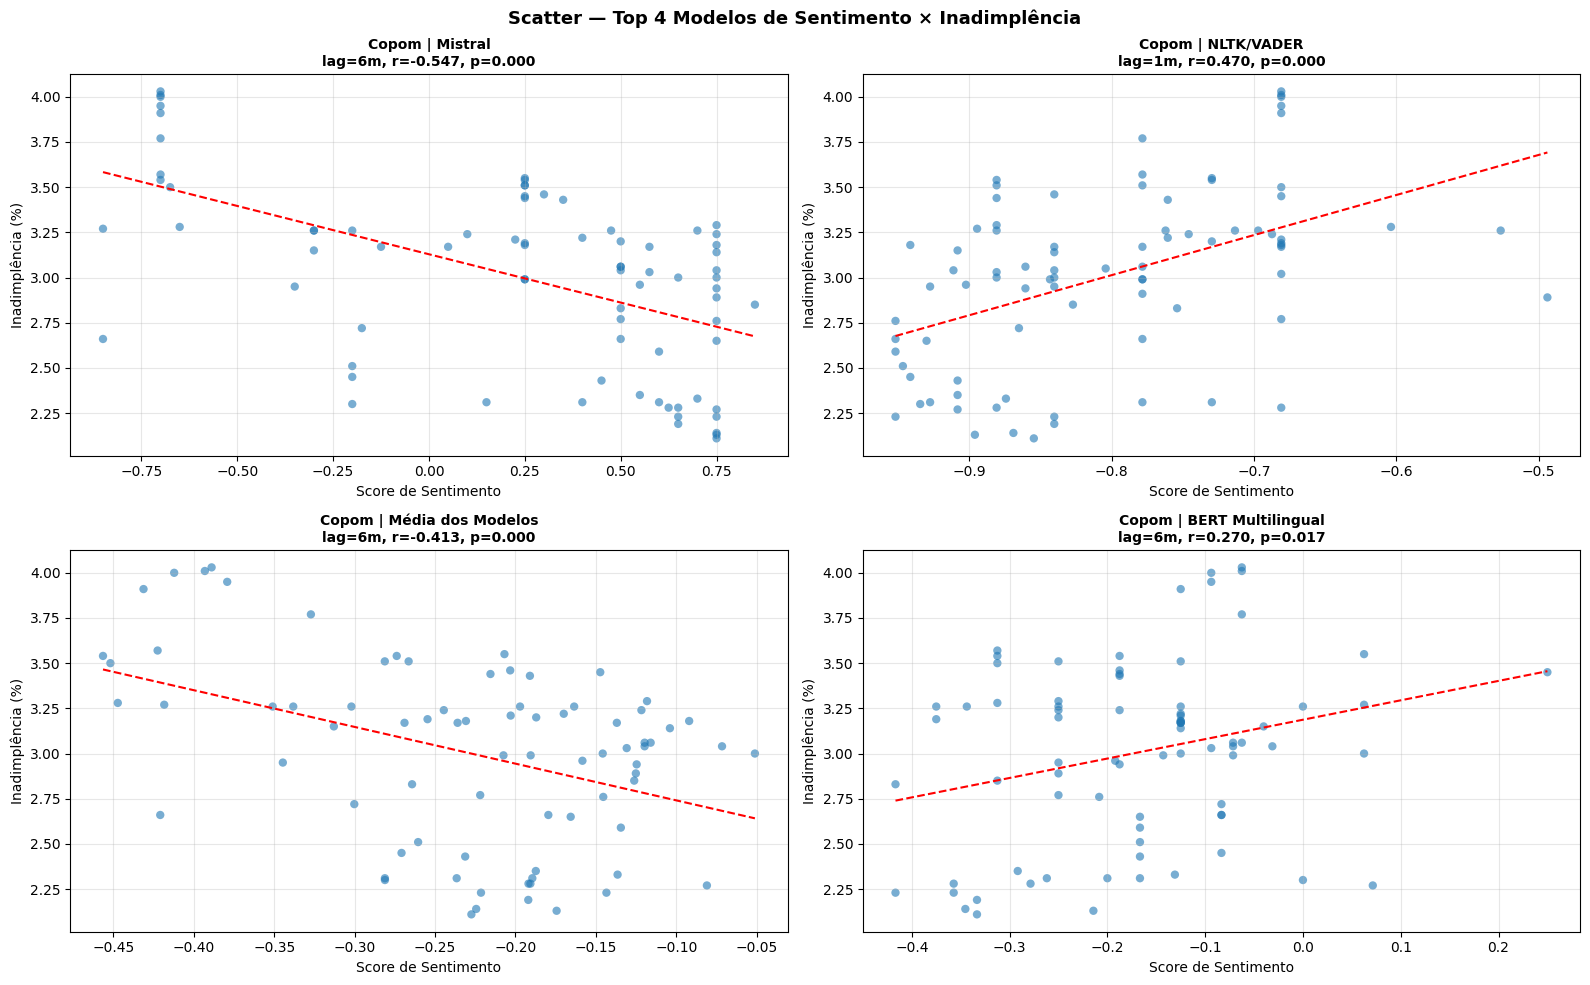

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (_, row) in zip(axes, top4.iterrows()):

    tipo_relatorio = row["Tipo Relatório"]
    col = row["col"]
    lag = int(row["Lag (meses)"])

    # Filtrar apenas o tipo de relatório selecionado
    df_tipo = (
        df_merged[df_merged["tipo_relatorio"] == tipo_relatorio]
        .sort_values("mes")
        .copy()
    )

    # Aplicar lag somente dentro do relatório analisado
    df_tipo["sent_lag"] = df_tipo[col].shift(lag)

    df_tmp = df_tipo[["inad_total", "sent_lag"]].dropna().rename(
        columns={
            "inad_total": "inad",
            "sent_lag": "sent"
        }
    )

    if len(df_tmp) < 5:
        ax.set_title(f"{tipo_relatorio} | {nomes_display.get(col, col)}\nDados insuficientes")
        ax.axis("off")
        continue

    # Correlação
    r, p = stats.pearsonr(df_tmp["inad"], df_tmp["sent"])

    # Scatter
    ax.scatter(
        df_tmp["sent"],
        df_tmp["inad"],
        alpha=0.6,
        edgecolors="none"
    )

    # Reta de tendência
    z = np.polyfit(df_tmp["sent"], df_tmp["inad"], 1)
    x_line = np.linspace(df_tmp["sent"].min(), df_tmp["sent"].max(), 100)

    ax.plot(
        x_line,
        np.poly1d(z)(x_line),
        "r--",
        linewidth=1.5
    )

    ax.set_title(
        f"{tipo_relatorio.capitalize()} | {nomes_display.get(col, col)}\n"
        f"lag={lag}m, r={r:.3f}, p={p:.3f}",
        fontweight="bold",
        fontsize=10
    )

    ax.set_xlabel("Score de Sentimento")
    ax.set_ylabel("Inadimplência (%)")
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Scatter — Top 4 Modelos de Sentimento × Inadimplência",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 9. Exportar base para Notebook 06

In [36]:
# Base principal: uma linha por mês
df_export = (
    df_merged[["mes", "inad_total"]]
    .drop_duplicates()
    .sort_values("mes")
    .reset_index(drop=True)
)

for _, row in top4.iterrows():

    tipo_relatorio = row["Tipo Relatório"]
    col = row["col"]
    lag = int(row["Lag (meses)"])

    # Filtrar apenas o tipo de relatório selecionado
    df_tipo = (
        df_merged[df_merged["tipo_relatorio"] == tipo_relatorio]
        .sort_values("mes")
        [["mes", col]]
        .copy()
    )

    # Aplicar lag somente dentro do tipo de relatório
    df_tipo[f"{col}_lag{lag}"] = df_tipo[col].shift(lag)

    # Criar nome padronizado da coluna final
    modelo_nome = (
        nomes_display.get(col, col)
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
    )

    nome_coluna_final = f"sent_{tipo_relatorio}_{modelo_nome}_lag{lag}"

    df_tipo = df_tipo[["mes", f"{col}_lag{lag}"]].rename(
        columns={f"{col}_lag{lag}": nome_coluna_final}
    )

    # Juntar com a base final
    df_export = df_export.merge(df_tipo, on="mes", how="left")

# Remover linhas sem valores após aplicação dos lags
df_export = df_export.dropna().reset_index(drop=True)

# Renomear mes para data, se quiser manter o padrão dos notebooks anteriores
df_export = df_export.rename(columns={"mes": "data"})

# Exportar base final
df_export.to_csv("base_sentimento_selecionado.csv", index=False)

print("base_sentimento_selecionado.csv salvo.")
print(f"Observações: {len(df_export)}")
print(f"Colunas: {list(df_export.columns)}")

df_export

base_sentimento_selecionado.csv salvo.
Observações: 78
Colunas: ['data', 'inad_total', 'sent_copom_mistral_lag6', 'sent_copom_nltk_vader_lag1', 'sent_copom_média_dos_modelos_lag6', 'sent_copom_bert_multilingual_lag6']


,data,inad_total,sent_copom_mistral_lag6,sent_copom_nltk_vader_lag1,sent_copom_média_dos_modelos_lag6,sent_copom_bert_multilingual_lag6
0,2019-07-01,3.06,0.500,-0.77830,-0.119692,-0.071429
1,2019-08-01,3.04,0.500,-0.84020,-0.119692,-0.071429
2,2019-09-01,3.06,0.500,-0.86045,-0.115943,-0.062500
3,2019-10-01,3.03,0.575,-0.88070,-0.130848,-0.093750
4,2019-11-01,3.00,0.650,-0.84020,-0.145753,-0.125000
...,...,...,...,...,...,...
73,2025-08-01,3.95,-0.700,-0.68080,-0.379278,-0.093750
74,2025-09-01,3.91,-0.700,-0.68080,-0.431325,-0.125000
75,2025-10-01,4.00,-0.700,-0.68080,-0.412255,-0.093750
76,2025-11-01,4.01,-0.700,-0.68080,-0.393185,-0.062500
